In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../../datasets/placement_SLR.csv')
df.shape

(200, 2)

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


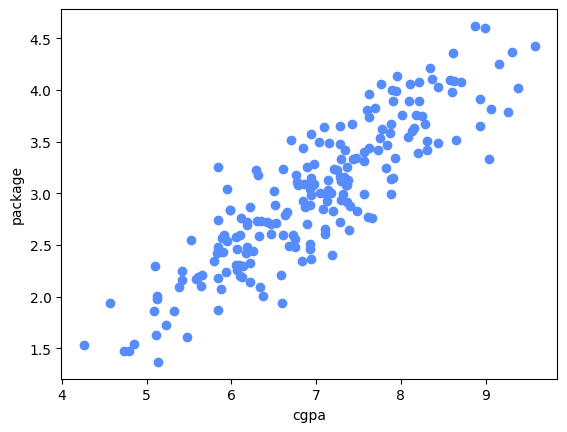

In [4]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [5]:
x = df.iloc[:,:1]
y = df.iloc[:,1:2]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [7]:
X_train

,cgpa
134,7.20
66,5.11
26,8.31
113,6.94
168,8.65
...,...
67,6.51
192,8.25
117,7.12
47,5.84


In [8]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
X_test

,cgpa
18,6.94
170,6.22
107,6.33
98,7.69
177,7.09
182,5.88
5,7.89
146,6.07
12,8.94
152,7.37


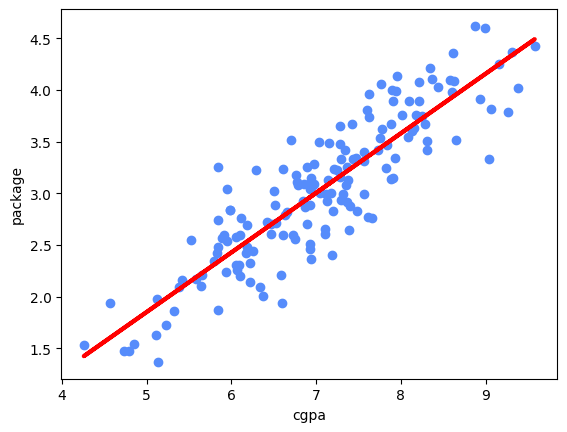

In [10]:
plt.scatter(X_train, y_train)
plt.plot(X_train, reg.predict(X_train), color='red', linewidth=3)
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [11]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Mean Absolute Error: 0.25524334486204076
Mean Squared Error: 0.10221131059334207
Root Mean Squared Error: 0.31970503685951224
R2 Score: 0.7297167943957027


In [12]:
X_test.shape

(40, 1)

In [13]:
R2score = 1 - (1 - r2) * (40 -1) / (40 - 1 - 1)
print('Adjusted R2 Score:', R2score)

Adjusted R2 Score: 0.7226040784587475


Mathematical intuition

In [14]:
df2 = df.copy()
df2['random_feature'] = np.random.rand(df.shape[0])
df2 = df2[['cgpa', 'random_feature', 'package']]

In [15]:
df2

,cgpa,random_feature,package
0,6.89,0.275894,3.26
1,5.12,0.381945,1.98
2,7.82,0.495544,3.25
3,7.42,0.421139,3.67
4,6.94,0.722943,3.57
...,...,...,...
195,6.93,0.764862,2.46
196,5.89,0.363108,2.57
197,7.21,0.100491,3.24
198,7.63,0.358974,3.96


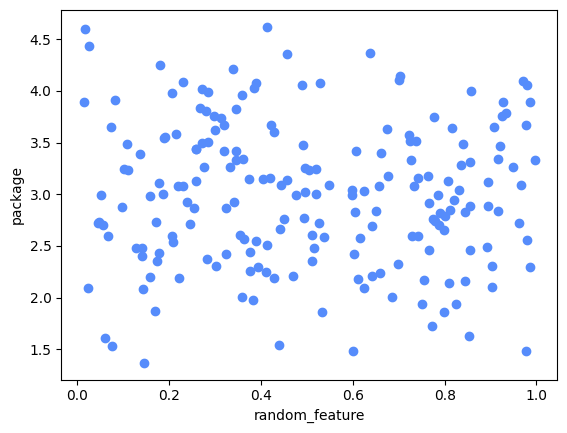

In [16]:
plt.scatter(df2['random_feature'], df2['package'])
plt.xlabel('random_feature')
plt.ylabel('package')
plt.show()

In [17]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(df2.iloc[:,0:2], df2.iloc[:,-1], test_size=0.2, random_state=0)

In [18]:
X_train2

,cgpa,random_feature
134,7.20,0.844003
66,5.11,0.853784
26,8.31,0.345795
113,6.94,0.281734
168,8.65,0.736956
...,...,...
67,6.51,0.855968
192,8.25,0.776134
117,7.12,0.598284
47,5.84,0.949503


In [19]:
reg2 = LinearRegression()
reg2.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred2 = reg2.predict(X_test2)
y_pred2

array([2.96536437, 2.55144314, 2.61867395, 3.3993822 , 3.06073102,
       2.35388004, 3.52167452, 2.4730225 , 4.12885555, 3.22108517,
       2.12207862, 3.19381946, 2.54366254, 3.05492127, 3.36464298,
       2.85538405, 2.62363591, 2.82531402, 2.36585831, 2.91481821,
       3.16641197, 2.33708763, 3.50247784, 3.99111985, 2.2019916 ,
       1.90739929, 3.08698152, 2.6102099 , 1.92287628, 1.90350438,
       2.91246356, 3.69173219, 2.59644922, 2.09218917, 2.51514407,
       3.65118127, 3.17711762, 2.97297735, 3.82975665, 2.49910236])

In [21]:
print('Mean Squared Error:', mean_squared_error(y_test2, y_pred2))

Mean Squared Error: 0.10202688112200833


In [22]:
print('R2 Score:', r2_score(y_test2, y_pred2))

R2 Score: 0.7302044917790023


In [23]:
print('Adjusted R2  Score:', 1 - (1 - r2_score(y_test2, y_pred2)) * (40 - 1) / (40 - 2 - 1))

Adjusted R2  Score: 0.7156209507940835


In [28]:
df3 = df.copy()
df3['iq'] = df2['package'] + (np.random.randint(-12,12,200)/10)
df3 = df3[['cgpa', 'iq', 'package']]

In [29]:
df3

,cgpa,iq,package
0,6.89,2.56,3.26
1,5.12,1.28,1.98
2,7.82,2.05,3.25
3,7.42,3.07,3.67
4,6.94,3.17,3.57
...,...,...,...
195,6.93,2.46,2.46
196,5.89,1.77,2.57
197,7.21,3.14,3.24
198,7.63,4.06,3.96


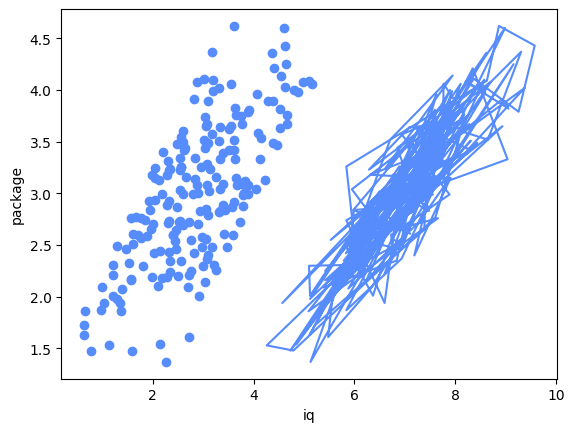

In [31]:
plt.scatter(df3['iq'], df3['package'])
plt.xlabel('iq')
plt.ylabel('package')
plt.show()

In [32]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(df3.iloc[:,0:2], df3.iloc[:,-1], test_size=0.2, random_state=0)

In [33]:
reg3 = LinearRegression()
reg3.fit(X_train3, y_train3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_pred3 = reg3.predict(X_test3)

In [35]:
print('Mean Squared Error:', mean_squared_error(y_test3, y_pred3))

Mean Squared Error: 0.09197974136845766


In [36]:
print('R2 Score:', r2_score(y_test3, y_pred3))

R2 Score: 0.7567727171933913


In [37]:
print('Adjusted R2  Score:', 1 - (1 - r2_score(y_test3, y_pred3)) * (40 - 1) / (40 - 2 - 1))

Adjusted R2  Score: 0.7436252965011423
